<h2>Modelling Sea floor Oxygen Concentration using data from the CMEMS Data Store</h2>

<hr>
<h4><strong>Data Used</strong></h4>
<ul>
    <li>Copernicus Marine Data</li><br>

| Dataset | CMEMS product ID| CMEMS product<br>description | Variable | Product User Manual |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|
| Baltic Sea Biogeochemistry Analysis and Forecast | BALTICSEA_ANALYSISFORECAST_BGC_003_007| <a href="https://data.marine.copernicus.eu/product/BALTICSEA_ANALYSISFORECAST_BGC_003_007/description" target="_blank">Description</a> | Sea floor Dissolved Oxygen Concentration (o2b) | <a href="https://documentation.marine.copernicus.eu/PUM/CMEMS-BAL-PUM-003-006-007.pdf" target="_blank">User Manual</a> |
  </ul>
 <ul>   
   <li>Coastal water areas (KVF)

| Dataset | Organisation | Metadata |
|:--------------------:|:-----------------------:|:-------------:|
| VM Vattenförekomster kustvatten 2016-2021 |<a href="https://viss.lansstyrelsen.se/" target="_blank">VISS </a> |<a href="https://ext-geodatakatalog.lansstyrelsen.se/GeodataKatalogen/srv/api/records/GetMetaDataById?id=ec8c278f-37a5-4fb3-971f-2920ab22609f" target="_blank">Link</a>|
</ul>

<hr>
<h4><strong>Learning Outcomes</strong></h4>

At the end of this notebook you will be able to:
<li> Set up the environment - install and activate the correct Conda enivironment (wekolab) and install required Pyhon libararies
<li> Connect to the Copernicus Marine Service
<li> Load and visualize Sea floor Oxygen Concentration data (o2b)
<li> Apply thresholds to classify environmental conditions (Hypoxic and Anoxic areas)
<li> Create maps showing hypoxic and anoxic zones over the full region
<li> Read and process coastal water areas (KVF) from shapefiles
<li> Calcualte the percentage and total area of hypoxic and anoxic conditions per KVF
<li> Visualize and summarize classification results
<hr>
<h4><strong>Outline</strong></h4>
Hypoxia at seafloor is a parameter that is used in the assessment of ecological status under the Swedish national environmental quality standards. Hypoxia is defined as oxygen concentrations ≤ 2 ml/l sea water and anoxic conditions as ≤ 0 ml/l sea water. Hypoxia at seafloor is quantified as the proportion of seafloor with hypoxia. In the national Swedish monitoring program, this parameter is measured at the deepest areas of monitored coastal water zones in profiles from the surface to the seafloor. However, only a few of the Swedish coastal water zones are included in the monitoring.  

<hr>
<h4><strong>References</strong></h4>
<ul>
<li>Hansson, M., & Viktorsson, L. (2025). Syresituationen i Östersjön 2024 (RO 80). Sveriges meterologiska och hydrologiska institut. https://www.smhi.se/publikationer-fran-smhi/sok-publikationer/2025-04-14-syresituationen-i-ostersjon-2024</li>
<li>
</ul>

<hr>

<div class="alert alert-block alert-warning"> 
We start by importing all libraries that will be used in this notebook. This notebook can be run in a Wekeolab Jupyter workspace after installing the extra libraries listed in "Prerequisites." An environment file is also included in this repository for users who would prefer to build their own environment.
</div>

<h4><strong>Contents</strong></h4>

<ol>   
<li>Access the Sea floor Disolved Oxygen Concentration (o2b) parameter</li>
<li>Calculate and Visualizing Hypoxic and Anoxic Areas in the Full Region</li>
<li>Read in the coast water areas (KVF)</li>
<li>Hypoxia and Anoxia within Coastal Water Areas (KVF)</li>
</ol>
<hr>

<div class="alert alert-block alert-warning"> 
<h4>Prerequisites:</h4>
<ol>
   <li><strong><em>Wekeo account: </em></strong> Create an account via "Register" here: <em>https://wekeo.copernicus.eu/</em></li>
   <li><strong><em>Copernicus Marine account: </em></strong> Create an account here: <em>https://data.marine.copernicus.eu/register</em></li>
   <li><strong><em>Two external libraries </em></strong> must be installed in the wekeolab python environment.</li>
   <ul>
      <li>open a terminal in the wekeolab JupyterHub environment</li>
      <li>activate the wekeolab environment <code style="background:red;color:white">conda activate wekeolab</code></li>
      <li>upgrade to copernicusmarine 2.0 <code style="background:red;color:white">conda install -c conda-forge copernicusmarine</code></li>
      <li>execute the following commands to install the required packages in the wekeolab environment:</li>
         - <code style="background:red;color:white">conda install -c conda-forge xcube xcube-cmems copernicusmarine bottleneck openeo hvplot geoviews -y</code><br>
</div>
<hr>

In [2]:
from xcube.core.store import find_data_store_extensions
from xcube.core.store import get_data_store_params_schema
from xcube.core.store import new_data_store
from xcube.core.dsio import open_cube
from xcube.core.geom import clip_dataset_by_geometry

from xcube_cmems.store import CmemsDataStore
import xcube_cmems
from xcube.core.gridmapping import GridMapping
from xcube.core.resampling import resample_in_space

from IPython.display import JSON

import os
import numpy as np
import xarray as xr
import rioxarray
import bottleneck
import copernicusmarine as cm 

import shapely
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs          
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature

#hvplot
import hvplot.xarray
import panel as pn
pn.extension()
import hvplot.pandas

from matplotlib.colors import ListedColormap
from shapely.geometry import Polygon
from collections import Counter
import matplotlib.patches as mpatches

<div class="alert alert-info" role="alert">

## <a id='section1'></a>1. Access the Sea floor Dissolved Oxygen Concentration (o2b) parameter
[Back to top](#TOC_TOP)

</div>

<div class="alert alert-block alert-warning"> 
We first need to provide our username and password from our free account on the Copernicus Marine website:
</div>

In [ ]:
user = "username"
pwd = "password"
cred_path = os.path.expanduser("~/.copernicusmarine/.copernicusmarine-credentials")
if os.path.exists(cred_path):
    os.remove(cred_path)

cm.login(user, pwd)

INFO - 2025-06-13T12:38:44Z - Credentials file stored in /home/jovyan/.copernicusmarine/.copernicusmarine-credentials.


True

<div class="alert alert-block alert-warning"> 
Next we will check to see that "cmems" is listed as an available data store in our xcube data stores. If you do not see "cmems" listed please return to "Prerequisites" and install the xcube-cmems library.
</div>

In [4]:
JSON({e.name: e.metadata for e in find_data_store_extensions()})

<IPython.core.display.JSON object>

<div class="alert alert-block alert-warning"> 
We are now ready to remotely access a data cube time series for o2b that are used to calculate the bottom oxygen during 01 May to September 30 2024. 

If you would like to change the geographic area please adjust the lat/long supplied in the "bbox" variable. If you would like to change the time scale please change the variables for "start" and "end" dates. After the data is loaded we take a look at the resulting data cube. We see that we have a 3D dataset comprised of 153 days within a rectangular area. The o2b variabel is stored in the data cube. Note that the time series data cube is loaded in as a Dask array so that the full dataset is not loaded into server memory until data is manipulated in some way. This allows for much faster data loading, but if you attempt to access a very long time series the server can still be overloaded and crash!
</div>

In [5]:
ds = cm.open_dataset(
    dataset_id = 'cmems_mod_bal_bgc_anfc_P1D-m',
    minimum_longitude=9.5,
    maximum_longitude=13,
    minimum_latitude=55,
    maximum_latitude=60,
    # enter start and end dates
    start_datetime = "2024-05-01",
    end_datetime = "2024-09-30",
    variables = ['o2b']
)
ds

INFO - 2025-06-13T12:38:46Z - Dataset version was not specified, the latest one was selected: "202411"
INFO - 2025-06-13T12:38:46Z - Dataset part was not specified, the first one was selected: "default"
INFO - 2025-06-13T12:38:47Z - Service was not specified, the default one was selected: "arco-time-series"


<xarray.Dataset> Size: 23MB
Dimensions:    (time: 153, latitude: 300, longitude: 126)
Coordinates:
  * latitude   (latitude) float32 1kB 55.01 55.02 55.04 ... 59.96 59.97 59.99
  * longitude  (longitude) float32 504B 9.514 9.542 9.569 ... 12.93 12.96 12.99
  * time       (time) datetime64[ns] 1kB 2024-05-01 2024-05-02 ... 2024-09-30
Data variables:
    o2b        (time, latitude, longitude) float32 23MB ...
Attributes: (12/18)
    Conventions:            CF-1.0
    comment:                Data on cropped native product grid. Horizontal v...
    compression:            yes
    contact:                servicedesk.cmems@mercator-ocean.eu
    creation_date:          2024-11-20 09:24:59
    easternmost_longitude:  30.208656311035156
    ...                     ...
    source:                 CMEMS BAL MFC NEMO model output converted to NetCDF
    southernmost_latitude:  53.008296966552734
    start_date:             2024-11-25 12:00:00
    stop_date:              2024-11-25 12:00:00
    title:                  CMEMS ERGOM daily integrated model fields
    westernmost_longitude:  9.041582107543945

<div class="alert alert-block alert-warning"> 
We will now read in some basic open source shapefiles of land and ocean surfaces to give our maps more context
</div>

In [6]:
# Read in some map background features

land = shpreader.natural_earth('10m', 'cultural', 'admin_0_countries')
land = cfeature.ShapelyFeature(shpreader.Reader(land).geometries(), ccrs.PlateCarree(), edgecolor='black', facecolor='lightgray', lw=0.2)

ocean = shpreader.natural_earth('10m', 'physical', 'ocean')
ocean = cfeature.ShapelyFeature(shpreader.Reader(ocean).geometries(), ccrs.PlateCarree(), edgecolor='none', facecolor='lightblue')

<div class="alert alert-block alert-warning"> 
Now we will visualize the first 4 days of our o2b data.
</div>

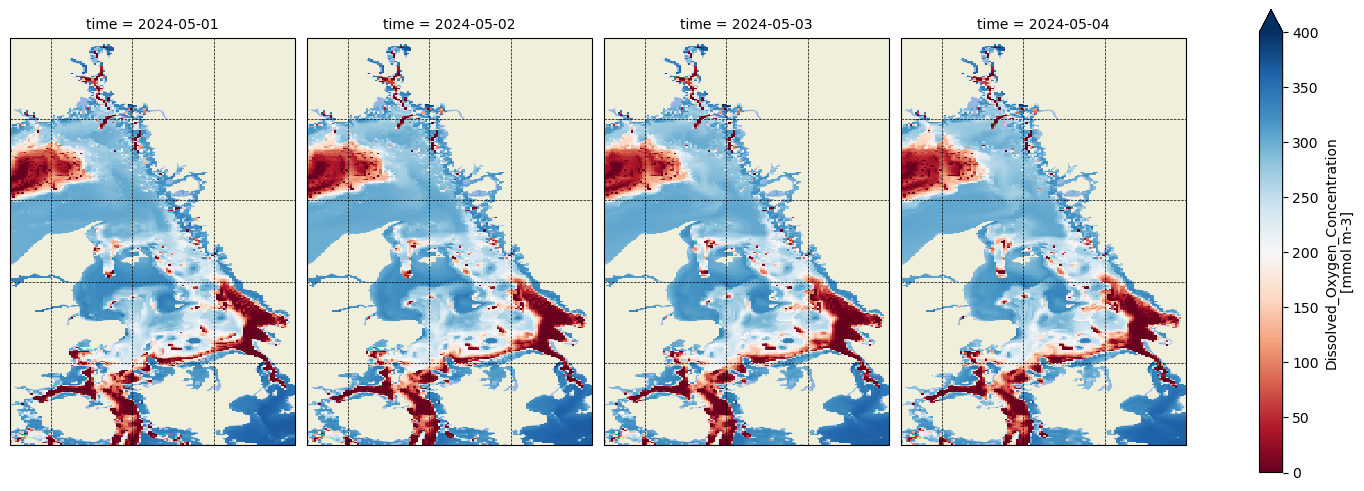

In [7]:
fig = ds.o2b.isel(time=slice(0,4)).plot(
    transform=ccrs.PlateCarree(),
    col='time',
    subplot_kws=dict(projection=ccrs.PlateCarree()),
    vmin=0, 
    vmax=400,
    cmap='RdBu',
    figsize=(15,5),
    zorder=2
)

[ax.add_feature(cfeature.LAND, zorder=0)  for ax in fig.axs.flatten()]
[ax.add_feature(cfeature.OCEAN, zorder=0) for ax in fig.axs.flatten()]

for ax in fig.axs.flat:
    g1 = ax.gridlines(color='black', linewidth=0.5, linestyle='--')
    g1.xlocator = mticker.FixedLocator(np.arange(10, 14, 1))
    g1.ylocator = mticker.FixedLocator(np.arange(55, 60, 1))

<div class="alert alert-info" role="alert">

## <a id='section1'></a>2. Calculate and Visualizing Hypoxic and Anoxic Areas in the Full Region
[Back to top](#TOC_TOP)

</div>

<div class="alert alert-block alert-warning"> 
This step converts the hypoxia threshold from 2 mL/L to mmol/m3 (~89 mmol) and creates a binary mask where oxygen is below this threshold (hypoxic)
</div>

In [8]:
# remote Time dimension and average for each pixel across time series
ds_mean = ds.mean(dim='time', skipna=True)

# Hypoxia limit
value_ml_per_l = 2 #Hypoxia <2 ml/l (SMHI) ~89 mmol/m3
value_mmol_per_m3 = value_ml_per_l / 0.0224
hypoxic_mask = xr.where(ds_mean.o2b < value_mmol_per_m3, 1, 0)
hypoxic_mask = hypoxic_mask.where(~np.isnan(ds_mean.o2b))

<div class="alert alert-block alert-warning"> 
This step identifies areas with low oxygen concentrations on the seafloor, using thresholds. We define hypoxia as oxygen levels below 89 mmol/m³, which corresponds to 2 ml/l, a threashold used by the Swedish Meterological and Hydrological Institute (Hansson, M., & Viktorsson, L. (2025)). Anoxia is defined as oxygen levels less than or equal to 0 mmol/m³.
</div>

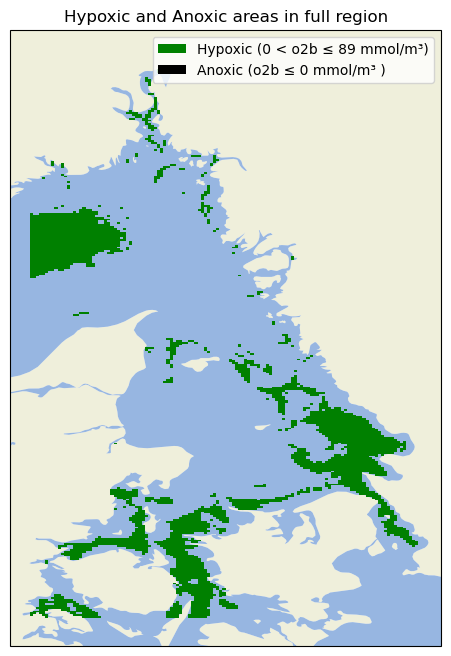

In [9]:
# Define oxygen data from ds_mean
o2b = ds_mean.o2b

# Classify the data 2 <= Anoxic (mmol/m3), 1 = Hypoxic (0-89), NaN = outher
classified = xr.full_like(o2b, np.nan)
classified = xr.where((o2b <= 0), 2, classified)
classified = xr.where((o2b > 0) & (o2b < 89), 1, classified)

# Define color 1 = green (hypoxic), 2 = black (anoxic)
class_colors = ["green", "black"]
cmap = ListedColormap(class_colors)
vmin, vmax = 1, 2 

# Plot the classification map
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
cbar = classified.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False)

# Add background map 
ax.add_feature(cfeature.LAND, zorder=0)    
ax.add_feature(cfeature.OCEAN, zorder=0)   

# Set map extent
bounds = ds_mean.o2b.where(~np.isnan(classified)).rio.bounds()
minx, miny, maxx, maxy = bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# Title and labels
ax.set_title("Hypoxic and Anoxic areas in full region")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add legend
legend_elements = [
    mpatches.Patch(facecolor='green', label='Hypoxic (0 < o2b ≤ 89 mmol/m³)'),
    mpatches.Patch(facecolor='black', label='Anoxic (o2b ≤ 0 mmol/m³ )')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()

In [10]:
# Definie colormap and classes
class_colors = ['green', 'black']  # 1=hypoxic, 2=anoxic
cmap = class_colors

# Plot map
classified.hvplot.quadmesh(
    x='longitude',
    y='latitude',
    cmap=cmap,
    clim=(1, 2),
    colorbar=True,
    tiles=True,
    frame_height=500,
    frame_width=700,
    title='Hypoxic and Anoxic areas (seafloor)',
    alpha=0.9
)

:Overlay
   .Tiles.I    :Tiles   [x,y]
   .QuadMesh.I :QuadMesh   [x,y]   (o2b)

<div class="alert alert-info" role="alert">

## <a id='section1'></a>3. Read in the coast water areas (KVF)
[Back to top](#TOC_TOP)

</div>

<div class="alert alert-block alert-warning"> 
We now load and clip the coastal water areas (KVF) to match our study area..
</div>

<Axes: >

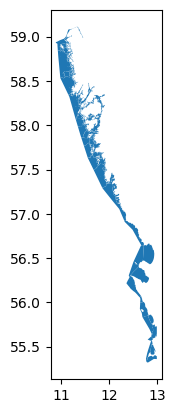

In [11]:
# read in kustvattenförekomster and clip to the study area

kvf = os.path.join('external_data', 'VM', 'vm.Kustvatten_Vattenforekomster_2016_1.shp')
kvf = gpd.read_file(kvf)
kvf = kvf.to_crs(4326)

c =  {'NW': [9.5, 60],
      'NE': [13, 60],
      'SW': [9.5, 55],
      'SE': [13, 55]}

bb = Polygon([c['NW'], c['NE'], c['SE'], c['SW']])

kvf_clipped = kvf.clip(bb)
kvf_clipped.plot()

<div class="alert alert-block alert-warning"> 
Now we check out the geodataframe info.
</div>

In [12]:
kvf_clipped.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 121 entries, 574 to 499
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    121 non-null    int64   
 1   UUID        121 non-null    object  
 2   MS_CD       121 non-null    object  
 3   EU_CD       121 non-null    object  
 4   VISS_MS_CD  121 non-null    object  
 5   NAMN        121 non-null    object  
 6   TYP_NFS06   121 non-null    int64   
 7   TYPOMRKUST  121 non-null    object  
 8   CATEGORY    121 non-null    object  
 9   WB          121 non-null    object  
 10  District    121 non-null    object  
 11  COMP_AUTH   121 non-null    object  
 12  Country     121 non-null    object  
 13  Version     121 non-null    object  
 14  URL_VISS    121 non-null    object  
 15  ObjVer      121 non-null    object  
 16  GVatten     121 non-null    object  
 17  UTL_EU_CD   4 non-null      object  
 18  UTL_MS_CD   4 non-null      object  
 19  SHA

<div class="alert alert-block alert-warning"> 
We dissolve kvf by 'TYPOMRKUST' to find all coastal water areas that we are intrested in. 
</div>

In [13]:
kvf_dissolved = kvf_clipped.dissolve(by='TYPOMRKUST')
kvf_dissolved = kvf_dissolved.reset_index()

for row in kvf_dissolved.itertuples():
    print(f'Index {row.Index}: TYPOMRKUST <{row.TYPOMRKUST}>')

Index 0: TYPOMRKUST <1n>
Index 1: TYPOMRKUST <1s>
Index 2: TYPOMRKUST <2>
Index 3: TYPOMRKUST <25>
Index 4: TYPOMRKUST <3>
Index 5: TYPOMRKUST <4>
Index 6: TYPOMRKUST <5>
Index 7: TYPOMRKUST <6>
Index 8: TYPOMRKUST <7>


<div class="alert alert-block alert-warning"> 
Now we clip the mean value dataset after the costal water areas (KVF) and store each area in ds_mclipped.
</div>

In [14]:
# iteratively create list of the o2b mean dataset clipped by the TYPOMRKUST areas

hypoxic_mask = hypoxic_mask.rio.write_crs(4326)
ds_mclipped=[]
for index, row in kvf_dissolved.iterrows():
    aoi = hypoxic_mask.rio.clip([row['geometry']], all_touched=True)
    ds_mclipped.append(aoi)

<div class="alert alert-info" role="alert">

## <a id='section1'></a>4. Hypoxia and Anoxia within Coastal Water Areas (KVF)
[Back to top](#TOC_TOP)

</div>

<div class="alert alert-block alert-warning"> 
In this step we perform the classification of hypoxic (<89 mmol/m³) and anoxic (<=0 mmol/m³) conditions within each coastal water area (KVF). For each coastal water area (KVF), we create a separate map that shows where hypoxia and anoxia occur. Once all maps are generated, the total and percentage area of hypoxia and anoxia for each KVF is summarized in a final results table.

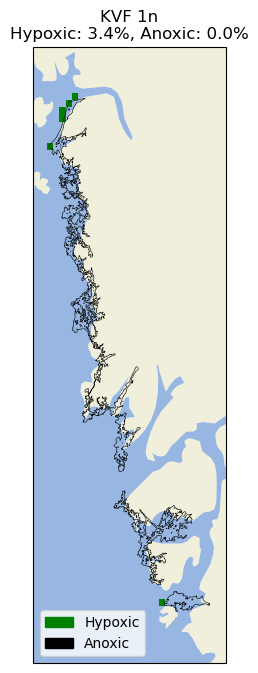

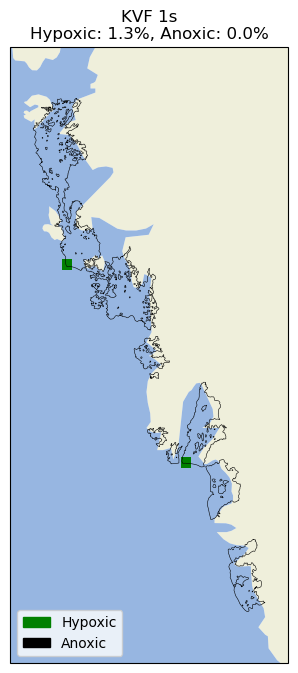

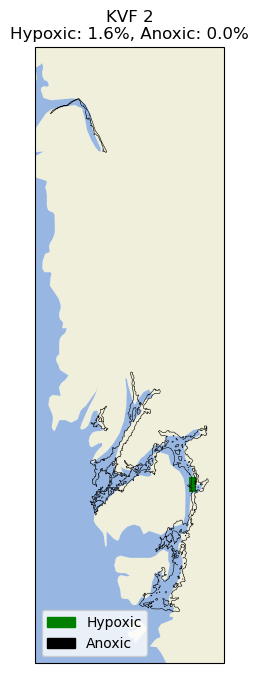

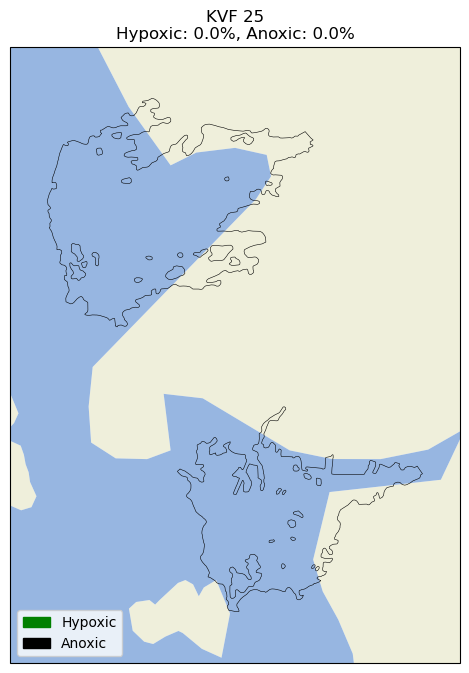

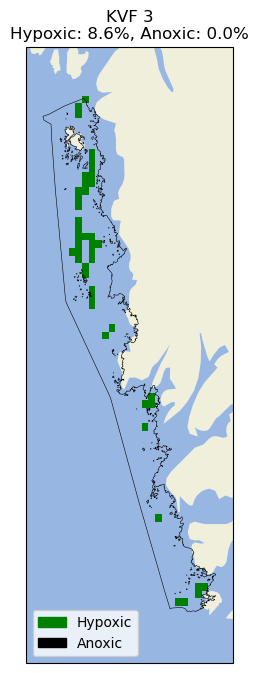

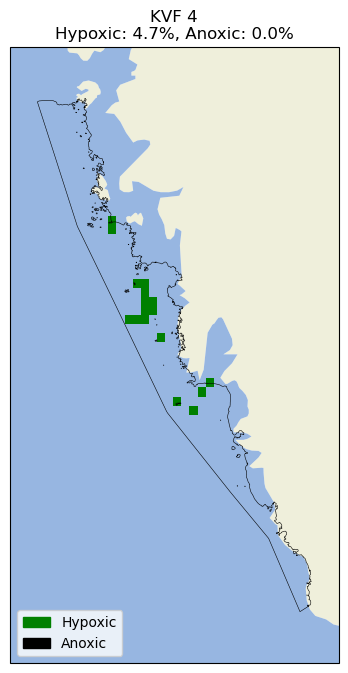

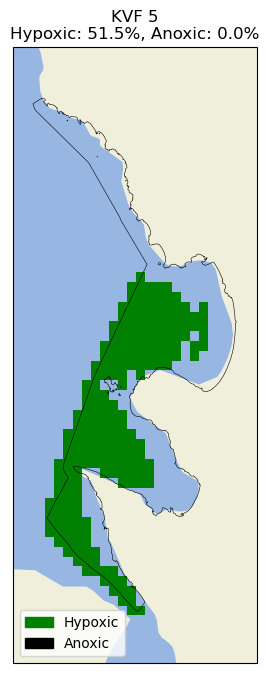

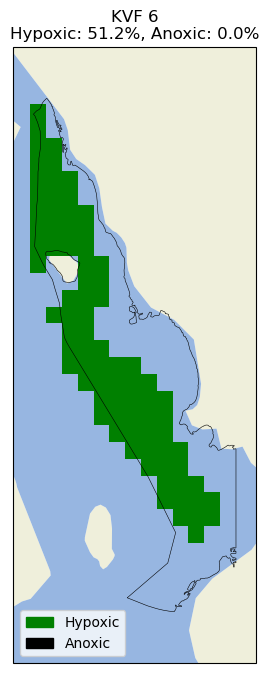

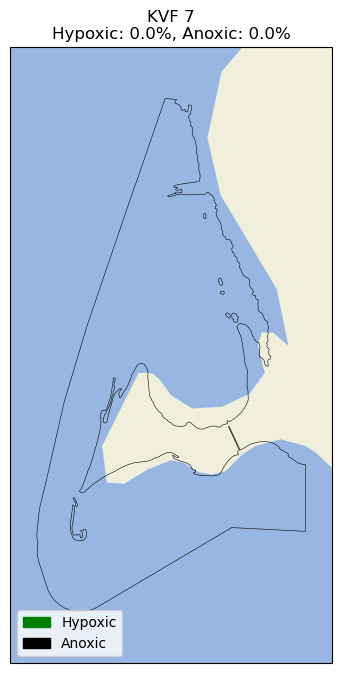

,Total area (km²),Hypoxic area (km²),Anoxic area (km²),Hypoxic %,Anoxic %
KVF,,,,,
1n,700,24,0,3.4,0.0
1s,604,8,0,1.3,0.0
2,504,8,0,1.6,0.0
25,104,0,0,0.0,0.0
3,2048,176,0,8.6,0.0
4,1436,68,0,4.7,0.0
5,1616,832,0,51.5,0.0
6,640,328,0,51.2,0.0
7,272,0,0,0.0,0.0


In [15]:
# Create a list to store results per coastal water area
results = []

# Define classification labels and color map
class_labels = {1: "Hypoxic", 2: "Anoxic"}
class_colors = ["green", "black"]  # 1 = Hypoxic, 2 = Anoxic
cmap = ListedColormap(class_colors)

# create dataArray that will hold the combined classification results for all processed water bodies
combined_array = None

# Loop through each coastal water area (KVF)
for ind in range(len(ds_mclipped)):
    
    # Get binary mask for current KVF area
    mask = ds_mclipped[ind]
    # Maks oxygen data to include only values inside current KVF polygon
    o2_values = ds_mean.o2b.where(mask == 1)  # Get oxygen values only inside the KVF

    # Classify each pixel: 2 = Anoxic (≤ 0 mmol/m³), 1 = Hypoxic (0–89 mmol/m³), NaN otherwise
    classified = xr.full_like(o2_values, np.nan)
    classified = xr.where((o2_values > 0) & (o2_values <= 89), 1, classified)
    classified = xr.where(o2_values <= 0, 2, classified)

    # Mask values outside the polygon to avoid showing classification there
    classified = classified.where(mask == 1)

    # Convert classified array to a DataArray for later merging
    class_da = xr.DataArray(
        classified,
        coords=o2_values.coords,
        dims=o2_values.dims
    )
    
    # Combine classifications across all KVF areas
    if combined_array is None:
        combined_array = class_da
    else:
        combined_array = combined_array.combine_first(class_da)

    # Calculate number of pixels in each class and create statistics
    pixel_area_km2 = 4
    total_pixels = mask.count().values
    hypoxic_pixels = (classified == 1).sum().values
    anoxic_pixels = (classified == 2).sum().values

    total_area_km2 = total_pixels * pixel_area_km2
    hypoxic_area_km2 = hypoxic_pixels * pixel_area_km2
    anoxic_area_km2 = anoxic_pixels * pixel_area_km2

    hypoxic_percent = (hypoxic_area_km2 / total_area_km2) * 100
    anoxic_percent = (anoxic_area_km2 / total_area_km2) * 100

    # Get name of the KVF area
    try:
        KVF_name = kvf_dissolved.iloc[ind]['TYPOMRKUST']
    except:
        KVF_name = f"KVF {ind}"

    # Save statistics to results table
    results.append({
        'KVF': KVF_name,
        'Total area (km²)': total_area_km2,
        'Hypoxic area (km²)': hypoxic_area_km2,
        'Anoxic area (km²)': anoxic_area_km2,
        'Hypoxic %': hypoxic_percent,
        'Anoxic %': anoxic_percent
    })

    # Plot the classified maps
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
    classified.plot(ax=ax, cmap=cmap, vmin=1, vmax=2, add_colorbar=False)

    # Overlay KVF boundary
    kvf_dissolved.iloc[[ind]].boundary.plot(ax=ax, edgecolor="black", lw=0.4)

    # Adjust map view to fit the polygon
    bounds = kvf_dissolved.iloc[ind].geometry.bounds
    minx, miny, maxx, maxy = bounds
    pad_x = (maxx - minx) * 0.1
    pad_y = (maxy - miny) * 0.1
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    # Add geographic background
    ax.add_feature(cfeature.LAND, zorder=0)    
    ax.add_feature(cfeature.OCEAN, zorder=0)

    # Add title and axis labels
    ax.set_title(f"KVF {KVF_name}\nHypoxic: {hypoxic_percent:.1f}%, Anoxic: {anoxic_percent:.1f}%", fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Create and add legend
    legend_patches = [
        mpatches.Patch(color=class_colors[i - 1], label=label)
        for i, label in class_labels.items()
    ]
    ax.legend(handles=legend_patches, loc='lower left')

    plt.show()

# Show final result table
df_results = pd.DataFrame(results)
df_results = df_results.set_index('KVF')
df_results[['Hypoxic %', 'Anoxic %']] = df_results[['Hypoxic %', 'Anoxic %']].round(1)
display(df_results)

<div class="alert alert-block alert-warning"> 
This step visualizes the combined classification of all coastal water areas in a single map. It uses the results from the previous classification step (Hypoxic and Anoxic areas)
</div>

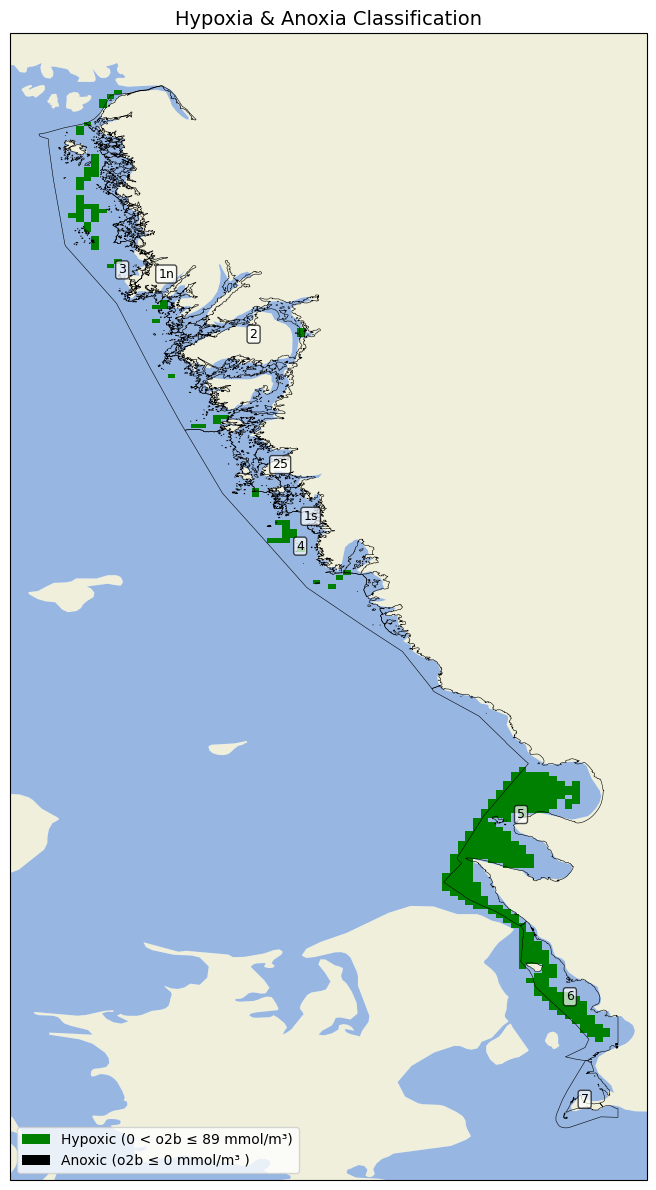

In [16]:
# Plot combined classification map
fig, ax = plt.subplots(1, 1, figsize=(15, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

img = combined_array.plot(
    ax=ax,
    cmap=cmap,
    vmin=1,
    vmax=2,
    add_colorbar=False
)

# Add legend
legend_elements = [
    mpatches.Patch(facecolor='green', label='Hypoxic (0 < o2b ≤ 89 mmol/m³)'),
    mpatches.Patch(facecolor='black', label='Anoxic (o2b ≤ 0 mmol/m³ )')
]
ax.legend(handles=legend_elements, loc='lower left')

# Plot boundaries
kvf_dissolved.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.4)

# Add labels on polygons
for idx, row in kvf_dissolved.iterrows():
    centroid = row.geometry.centroid
    label = str(row['TYPOMRKUST'])
    ax.text(
        centroid.x, centroid.y, label,
        fontsize=9, ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor='black', alpha=0.7)
    )

# Map extent and background
minx, miny, maxx, maxy = kvf_dissolved.total_bounds
pad_x = (maxx - minx) * 0.05
pad_y = (maxy - miny) * 0.05
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ax.add_feature(cfeature.LAND, zorder=0)    
ax.add_feature(cfeature.OCEAN, zorder=0)

# Title and layout
ax.set_title("Hypoxia & Anoxia Classification", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [17]:
# Plot classified O2B
chl_plot = combined_array.hvplot.quadmesh(
    x='longitude',
    y='latitude',
    cmap=['green', 'black'],   # 1 = Hypoxic, 2 = Anoxic
    clim=(1, 2),
    colorbar=True,
    tiles=True,
    alpha=0.9,
    frame_height=700,
    frame_width=800,
    title='Hypoxia & Anoxia Classification'
)

# Add KVF boundaries
boundary_plot = kvf_dissolved.hvplot(
    line_width=1,
    line_color='black',
    fill_alpha=0,
    tools=[],
    hover_cols=[],
    geo=True
)

# Combine to one interactive map
final_plot = chl_plot * boundary_plot
final_plot

/opt/conda/envs/wekeolab/lib/python3.11/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 11.0.0. Please consider upgrading.
  warnings.warn(


:Overlay
   .Tiles.I    :Tiles   [x,y]
   .QuadMesh.I :QuadMesh   [x,y]   (o2b)
   .Polygons.I :Polygons   [Longitude,Latitude]